# IBM Telco Customer Churn — Capstone Project

# Table of Contents
0. [Project Summary](#0-project-summary)
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
   - 2.1 [Categorical Features vs Churn](#21-categorical-features-vs-churn)
   - 2.2 [Numeric Features vs Churn](#22-numeric-features-vs-churn)
3. [Preprocessing](#3-preprocessing)
4. [Logistic Regression](#4-logistic-regression)
   - 4.1 [Fit & Evaluate](#41-fit--evaluate)
   - 4.2 [ROC Curve](#42-roc-curve)
5. [Random Forest](#5-random-forest)
   - 5.1 [Fit & Evaluate](#51-fit--evaluate)
6. [Gradient Boosting](#6-gradient-boosting)
   - 6.1 [Fit & Evaluate](#61-fit--evaluate)
7. [Cross Validation](#7-cross-validation)
8. [Predicted Churn Probabilities & Risk Tiers](#8-predicted-churn-probabilities--risk-tiers)
9. [Feature Importance](#9-feature-importance)
10. [SHAP Values](#10-shap-values)
11. [Results Summary](#11-results-summary)

---

# 0. Project Summary

## Problem Statement
Customer churn — when a customer stops using a service — is a major cost driver for telecom companies. Acquiring a new customer is estimated to cost more than retaining an existing one. The goal of this project is to **predict which customers are at risk of churning** and identify the key factors driving that risk, so the business can take targeted retention actions.

## Dataset
- **Source:** IBM Telco Customer Churn dataset (via Kaggle — `blastchar/telco-customer-churn`)
- **Size:** 7,043 customers × 21 features
- **Target variable:** `Churn` (Yes / No) — approximately **26.5% churn rate**
- **Features include:**
  - Demographics: `gender`, `SeniorCitizen`, `Partner`, `Dependents`
  - Account info: `tenure`, `Contract`, `PaymentMethod`, `PaperlessBilling`, `MonthlyCharges`, `TotalCharges`
  - Services: `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`

## Approach
| Step | Description |
|------|-------------|
| EDA | Visualize churn patterns across categorical and numeric features |
| Preprocessing | One-hot encode categoricals, scale numerics, 80/20 stratified train/test split |
| Modelling | Train and evaluate three models: Logistic Regression, Random Forest, Gradient Boosting |
| Evaluation | Compare models using AUC, F1, Precision, Recall and asymmetric cost (5:1 FN:FP penalty) |
| Cross Validation | 10-fold stratified CV on training set to validate model stability |
| Interpretability | Feature importance coefficients + SHAP values on best model |
| Output | Churn probability scores with Low / Medium / High risk tiers for each customer |

---

# 1. Setup & Data Loading

In [257]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import kagglehub
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix, roc_curve, auc,
    RocCurveDisplay, f1_score, precision_score, recall_score, roc_auc_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [258]:
# ----------------------------
# Load data via kagglehub
# ----------------------------

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [259]:
# Locate the CSV in the downloaded folder
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [260]:
df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")
df["OnlineSecurity"] = df["OnlineSecurity"].replace("No internet service", "No")
df["OnlineBackup"] = df["OnlineBackup"].replace("No internet service", "No")
df["DeviceProtection"] = df["DeviceProtection"].replace("No internet service", "No")
df["TechSupport"] = df["TechSupport"].replace("No internet service", "No")
df["StreamingTV"] = df["StreamingTV"].replace("No internet service", "No")
df["StreamingMovies"] = df["StreamingMovies"].replace("No internet service", "No")

# 2. Exploratory Data Analysis

In [261]:
# --- Basic summary ---
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [262]:
# --- Check for missing values ---
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [263]:
# --- Check for blank values ---
(df["TotalCharges"].astype(str).str.strip() == "").sum()
blank_rows = df[df["TotalCharges"].astype(str).str.strip() == ""]
blank_rows

#assume blanks to be 0 charge amount
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isna().sum()
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [264]:
# --- Churn rate (target variable distribution) ---
churn_rate = (df["Churn"] == "Yes").mean()
print(f"Overall churn rate: {churn_rate:.4f} ({churn_rate*100:.2f}%)")
print()
print(df["Churn"].value_counts())

Overall churn rate: 0.2654 (26.54%)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


## 2.1 Categorical Features vs Churn

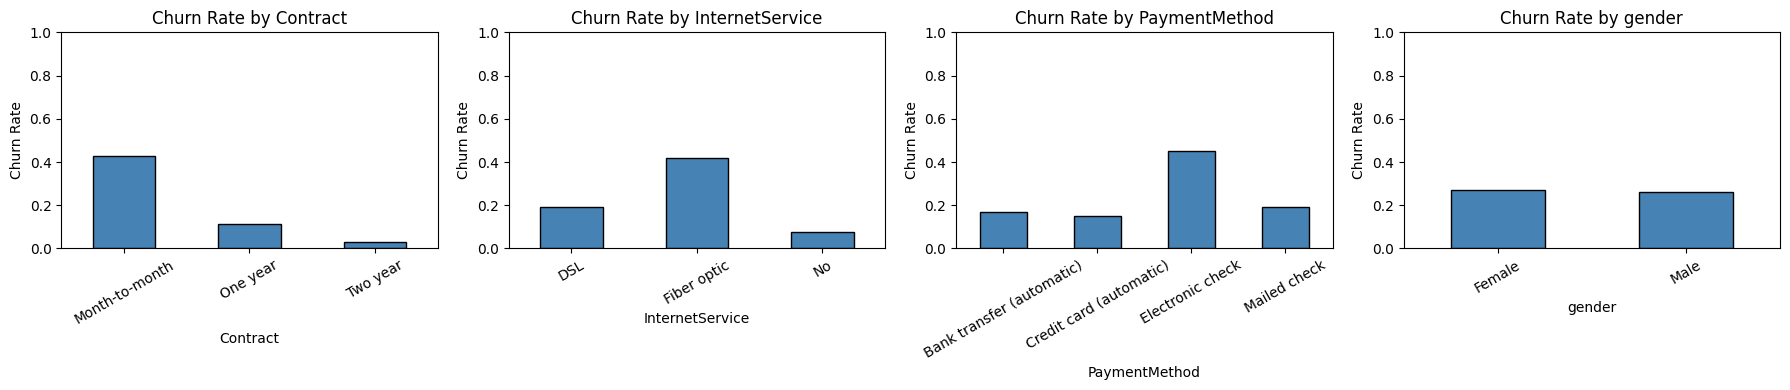

In [265]:
# --- Churn rate by key categorical features ---
cat_features = ["Contract", "InternetService", "PaymentMethod", "gender"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, cat_features):
    rates = df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean())
    rates.plot.bar(ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [266]:
#Convert churn to 0/1
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
df["Churn"].value_counts(normalize=True)

def churn_rate_table(col):
    t = (df.groupby(col)["Churn"]
           .agg(churn_rate="mean", churners="sum", customers="count")
           .sort_values("churn_rate", ascending=False))
    t["churn_rate"] = (t["churn_rate"] * 100).round(2)
    return t

key_cats = ["Contract", "PaymentMethod", "InternetService", "TechSupport", "OnlineSecurity",
            "PaperlessBilling", "SeniorCitizen", "Partner", "Dependents"]

for c in key_cats:
    if c in df.columns:
        print("\n", c)
        display(churn_rate_table(c))


 Contract


,churn_rate,churners,customers
Contract,,,
Month-to-month,42.71,1655,3875
One year,11.27,166,1473
Two year,2.83,48,1695



 PaymentMethod


,churn_rate,churners,customers
PaymentMethod,,,
Electronic check,45.29,1071,2365
Mailed check,19.11,308,1612
Bank transfer (automatic),16.71,258,1544
Credit card (automatic),15.24,232,1522



 InternetService


...

,churn_rate,churners,customers
SeniorCitizen,,,
1,41.68,476,1142
0,23.61,1393,5901



 Partner


,churn_rate,churners,customers
Partner,,,
No,32.96,1200,3641
Yes,19.66,669,3402



 Dependents


,churn_rate,churners,customers
Dependents,,,
No,31.28,1543,4933
Yes,15.45,326,2110


## 2.2 Numeric Features vs Churn

In [267]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[num_cols].describe(percentiles=[0.25, 0.5, 0.75]).T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


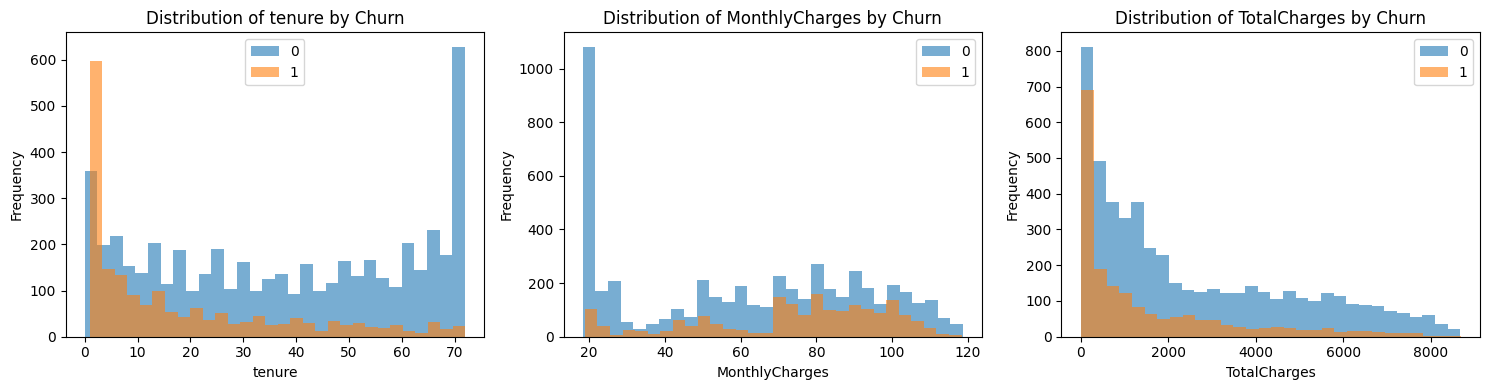

In [268]:
# --- Distribution of numeric features by Churn ---
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_features):
    df.groupby("Churn")[col].plot.hist(
        alpha=0.6, bins=30, ax=ax, legend=True
    )
    ax.set_title(f"Distribution of {col} by Churn")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

In [269]:
#create tenure levels
df["tenure_band"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6", "7-12", "13-24", "25-48", "49-72"]
)

band_tbl = churn_rate_table("tenure_band")
band_tbl

,churn_rate,churners,customers
tenure_band,,,
0-6,52.94,784,1481
7-12,35.89,253,705
13-24,28.71,294,1024
25-48,20.39,325,1594
49-72,9.51,213,2239


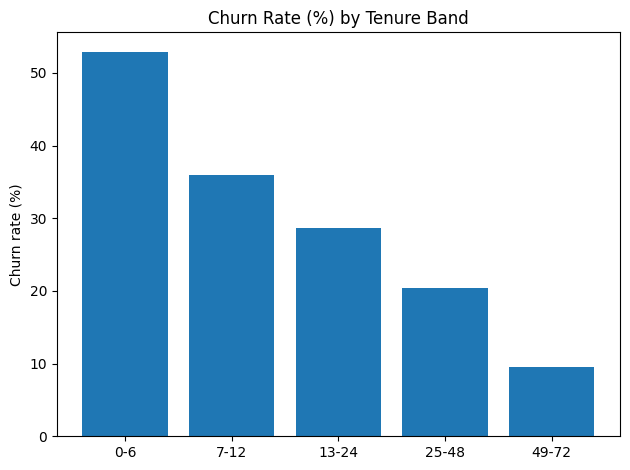

In [270]:
plt.figure()
plt.bar(band_tbl.index.astype(str), band_tbl["churn_rate"])
plt.title("Churn Rate (%) by Tenure Band")
plt.ylabel("Churn rate (%)")
plt.tight_layout()
plt.show()

In [271]:
#correlation matrix
corr = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr()
corr

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.826178,0.651174,1.000000,-0.198324
Churn,-0.352229,0.193356,-0.198324,1.000000


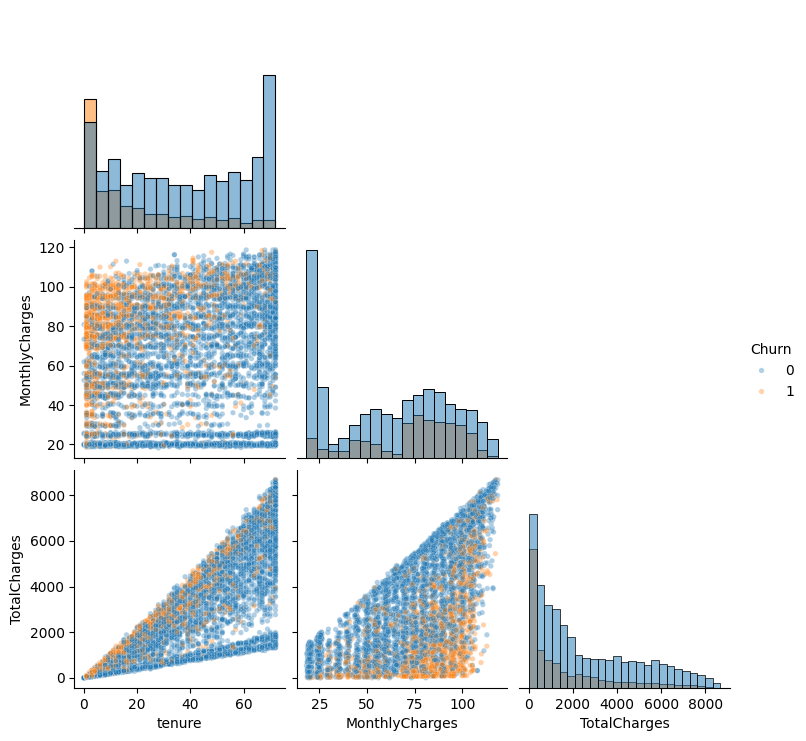

In [272]:
# pairplot
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

sns.pairplot(
    df[num_cols + ["Churn"]],
    hue="Churn",          # color by churn (0/1)
    diag_kind="hist",     # histograms on diagonal
    corner=True,
    plot_kws={"alpha": 0.35, "s": 15}
)

plt.show()

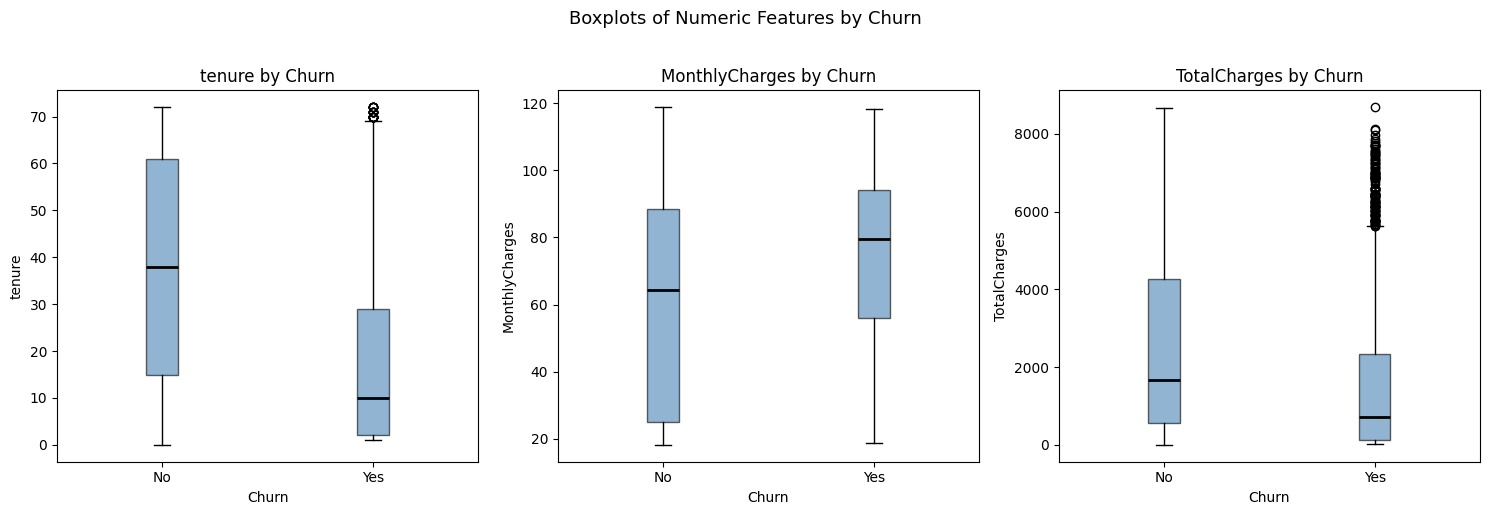

In [273]:
# --- Boxplots of numeric features by Churn ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, num_cols):
    churn_no  = df.loc[df["Churn"] == 0,  col]
    churn_yes = df.loc[df["Churn"] == 1, col]
    ax.boxplot(
        [churn_no, churn_yes],
        labels=["No", "Yes"],
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.6),
        medianprops=dict(color="black", linewidth=2)
    )
    ax.set_title(f"{col} by Churn")
    ax.set_xlabel("Churn")
    ax.set_ylabel(col)
plt.suptitle("Boxplots of Numeric Features by Churn", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 3. Preprocessing

In [274]:
# -------------------------------------------------------------------
# Separate features and target
# Separate categorical vs numeric columns
# -------------------------------------------------------------------
y = df["Churn"]
X = df.drop(columns=["Churn", "tenure_band"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train set shape: {X_train.shape}")
print(f"Test set shape:  {X_test.shape}")

Train set shape: (5634, 20)
Test set shape:  (1409, 20)


In [275]:
Xtest_ids = X_test["customerID"].copy()

X_train = X_train.drop(columns=["customerID"])
X_test = X_test.drop(columns=["customerID"])

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

In [276]:
# -------------------------------------------------------------------
# Build a ColumnTransformer preprocessor:
#   - OneHotEncoder  for categorical columns
#   - StandardScaler for numeric columns
# -------------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop"
)

# 4. Logistic Regression

## 4.1 Fit & Evaluate

In [277]:
# -------------------------------------------------------------------
# Confusion Matrix Function
# Asymmetric Cost Function
# -------------------------------------------------------------------
def conf_table(y_true, y_pred, row_name="Truth", col_name="Predicted"):
    labels = sorted(set(y_true) | set(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return pd.DataFrame(
        cm,
        index=pd.Index(labels, name=row_name),
        columns=pd.Index(labels, name=col_name)
    )


def cost_asymmetric(y_true, y_prob, weight1=5.0, weight0=1.0):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    pcut = 1.0 / (1.0 + weight1 / weight0)
    pred = (y_prob >= pcut).astype(int)
    fn = (y_true == 1) & (pred == 0)
    fp = (y_true == 0) & (pred == 1)
    cost = np.mean(weight1 * fn + weight0 * fp)
    return cost, pcut


In [278]:
# -------------------------------------------------------------------
# Logistic regression pipeline
# -------------------------------------------------------------------
logit_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("logit",      LogisticRegression(max_iter=5000, solver="lbfgs", random_state=RANDOM_STATE))
])

logit_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('logit', LogisticRegression(max_iter=5000, random_state=42))])

In [279]:
# --- In-sample (train) performance ---
prob_train_logit = logit_pipeline.predict_proba(X_train)[:, 1]
train_cost_logit, pcut_logit = cost_asymmetric(y_train, prob_train_logit, weight1=5, weight0=1)
pred_train_logit = (prob_train_logit >= pcut_logit).astype(int)

print(f"--- Logistic Regression: TRAIN (pcut = {pcut_logit:.4f}) ---")
print(f"Accuracy:         {accuracy_score(y_train, pred_train_logit):.4f}")
print(f"Asymmetric cost:  {train_cost_logit:.4f}")
print()
display(conf_table(y_train, pred_train_logit))

--- Logistic Regression: TRAIN (pcut = 0.1667) ---
Accuracy:         0.6825
Asymmetric cost:  0.4226



Predicted,0,1
Truth,,
0,2498,1641
1,148,1347


In [280]:
# --- Out-of-sample (test) performance ---
prob_test_logit = logit_pipeline.predict_proba(X_test)[:, 1]
test_cost_logit, _ = cost_asymmetric(y_test, prob_test_logit, weight1=5, weight0=1)
pred_test_logit = (prob_test_logit >= pcut_logit).astype(int)

print(f"--- Logistic Regression: TEST ---")
print(f"Accuracy:         {accuracy_score(y_test, pred_test_logit):.4f}")
print(f"Asymmetric cost:  {test_cost_logit:.4f}")
print(f"AUC:              {roc_auc_score(y_test, prob_test_logit):.4f}")
print()
display(conf_table(y_test, pred_test_logit))

--- Logistic Regression: TEST ---
Accuracy:         0.6785
Asymmetric cost:  0.4265
AUC:              0.8425



Predicted,0,1
Truth,,
0,619,416
1,37,337


## 4.2 ROC Curve

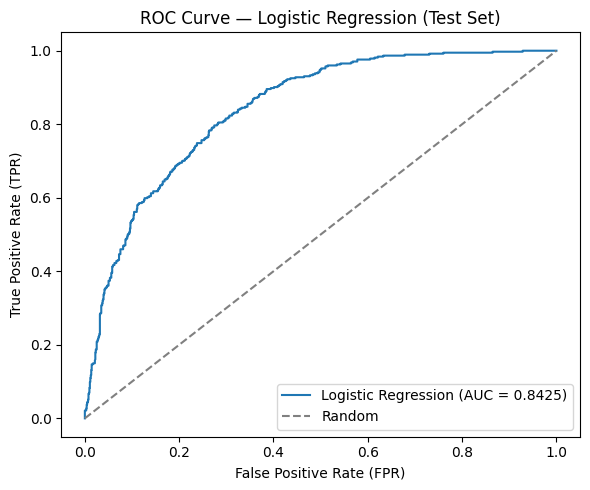

In [289]:
# -------------------------------------------------------------------
# ROC curve for logistic regression (test set)
# R equivalent: ROCR prediction + performance("tpr", "fpr")
# -------------------------------------------------------------------
fpr_logit, tpr_logit, _ = roc_curve(y_test, prob_test_logit)
auc_logit = auc(fpr_logit, tpr_logit)

plt.figure(figsize=(6, 5))
plt.plot(fpr_logit, tpr_logit, label=f"Logistic Regression (AUC = {auc_logit:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve — Logistic Regression (Test Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 5. Random Forest

## 5.1 Fit & Evaluate

In [282]:
# -------------------------------------------------------------------
# Random Forest pipeline
# -------------------------------------------------------------------
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("rf",         RandomForestClassifier(
                       n_estimators=500,
                       class_weight="balanced",
                       max_features="sqrt",
                       random_state=RANDOM_STATE,
                       n_jobs=-1
                   ))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=500, n_jobs=-1,
                                        random_state=42))])

In [283]:
# --- In-sample (train) performance ---
prob_train_rf = rf_pipeline.predict_proba(X_train)[:, 1]
train_cost_rf, pcut_rf = cost_asymmetric(y_train, prob_train_rf, weight1=5, weight0=1)
pred_train_rf = (prob_train_rf >= pcut_rf).astype(int)

print(f"--- Random Forest: TRAIN (pcut = {pcut_rf:.4f}) ---")
print(f"Accuracy:         {accuracy_score(y_train, pred_train_rf):.4f}")
print(f"Asymmetric cost:  {train_cost_rf:.4f}")
print()
display(conf_table(y_train, pred_train_rf))

--- Random Forest: TRAIN (pcut = 0.1667) ---
Accuracy:         0.9107
Asymmetric cost:  0.0893



Predicted,0,1
Truth,,
0,3636,503
1,0,1495


In [284]:
# --- Out-of-sample (test) performance ---
prob_test_rf = rf_pipeline.predict_proba(X_test)[:, 1]
test_cost_rf, _ = cost_asymmetric(y_test, prob_test_rf, weight1=5, weight0=1)
pred_test_rf = (prob_test_rf >= pcut_rf).astype(int)

print("--- Random Forest: TEST ---")
print(f"Accuracy:         {accuracy_score(y_test, pred_test_rf):.4f}")
print(f"Asymmetric cost:  {test_cost_rf:.4f}")
print(f"AUC:              {roc_auc_score(y_test, prob_test_rf):.4f}")
print()
display(conf_table(y_test, pred_test_rf))

--- Random Forest: TEST ---
Accuracy:         0.6849
Asymmetric cost:  0.4457
AUC:              0.8270



Predicted,0,1
Truth,,
0,637,398
1,46,328


# 6. Gradient Boosting

## 6.1 Fit & Evaluate

In [285]:
# -------------------------------------------------------------------
# Gradient Boosting pipeline
# -------------------------------------------------------------------
gb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("gb",         GradientBoostingClassifier(
                       n_estimators=500,
                       learning_rate=0.05,
                       max_depth=4,
                       subsample=0.8,
                       random_state=RANDOM_STATE
                   ))
])

gb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('gb',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=4,
                                            n_estimators=500, random_state=42,
                                            subsample=0.8))])

In [286]:
# --- In-sample (train) performance ---
prob_train_gb = gb_pipeline.predict_proba(X_train)[:, 1]
train_cost_gb, pcut_gb = cost_asymmetric(y_train, prob_train_gb, weight1=5, weight0=1)
pred_train_gb = (prob_train_gb >= pcut_gb).astype(int)

print(f"--- Gradient Boosting: TRAIN (pcut = {pcut_gb:.4f}) ---")
print(f"Accuracy:         {accuracy_score(y_train, pred_train_gb):.4f}")
print(f"Asymmetric cost:  {train_cost_gb:.4f}")
print()
display(conf_table(y_train, pred_train_gb))

--- Gradient Boosting: TRAIN (pcut = 0.1667) ---
Accuracy:         0.7748
Asymmetric cost:  0.2558



Predicted,0,1
Truth,,
0,2913,1226
1,43,1452


In [287]:
# --- Out-of-sample (test) performance ---
prob_test_gb = gb_pipeline.predict_proba(X_test)[:, 1]
test_cost_gb, _ = cost_asymmetric(y_test, prob_test_gb, weight1=5, weight0=1)
pred_test_gb = (prob_test_gb >= pcut_gb).astype(int)

print("--- Gradient Boosting: TEST ---")
print(f"Accuracy:         {accuracy_score(y_test, pred_test_gb):.4f}")
print(f"Asymmetric cost:  {test_cost_gb:.4f}")
print(f"AUC:              {roc_auc_score(y_test, prob_test_gb):.4f}")
print()
display(conf_table(y_test, pred_test_gb))

--- Gradient Boosting: TEST ---
Accuracy:         0.7147
Asymmetric cost:  0.4613
AUC:              0.8361



Predicted,0,1
Truth,,
0,695,340
1,62,312


# 7. Cross Validation

We use **10-fold stratified cross validation**

Four scoring criteria are evaluated: **ROC-AUC**, **F1**, **Precision**, and **Recall**.

In [288]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

In [242]:
models = {
    "Logistic Regression": logit_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline
}

cv_rows = []

for name, pipe in models.items():
    scores = cross_validate(
        pipe,
        X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_rows.append({
        "Model": name,
        "CV ROC_AUC Mean": scores["test_roc_auc"].mean(),
        "CV ROC_AUC Std": scores["test_roc_auc"].std(),
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Precision Mean": scores["test_precision"].mean(),
        "CV Recall Mean": scores["test_recall"].mean(),
        "CV F1 Mean": scores["test_f1"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV ROC_AUC Mean", ascending=False)
display(cv_results.round(4))

,Model,CV ROC_AUC Mean,CV ROC_AUC Std,CV Accuracy Mean,CV Precision Mean,CV Recall Mean,CV F1 Mean
0,Logistic Regression,0.8458,0.0146,0.8026,0.6549,0.5426,0.5926
2,Gradient Boosting,0.8404,0.0132,0.7978,0.6498,0.5218,0.5780
1,Random Forest,0.8265,0.0160,0.7875,0.6370,0.4683,0.5389


In [243]:
best_model_name = "Logistic Regression"
best_model = logit_pipeline

# 8. Predicted Churn Probabilities

In [244]:
best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('logit', LogisticRegression(max_iter=5000, random_state=42))])

In [245]:
# predicted probabilities on test set
y_test_prob = best_model.predict_proba(X_test)[:, 1]

# predicted class using default threshold 0.5
y_test_pred = (y_test_prob >= 0.5).astype(int)

In [246]:
def risk_band(p):
    if p < 0.30:
        return "Low"
    elif p < 0.60:
        return "Medium"
    else:
        return "High"

risk_levels = pd.Series(y_test_prob).apply(risk_band)

In [247]:
final_results_tableau = X_test.copy()

final_results_tableau["CustomerID"] = Xtest_ids.values
final_results_tableau["Churn_Actual"] = y_test.values
final_results_tableau["Churn_Predicted"] = y_test_pred
final_results_tableau["Churn_Probability"] = y_test_prob
final_results_tableau["Risk_Level"] = risk_levels.values

display(final_results_tableau.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,CustomerID,Churn_Actual,Churn_Predicted,Churn_Probability,Risk_Level
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,...,Two year,Yes,Credit card (automatic),114.05,8468.20,4376-KFVRS,0,0,0.046011,Low
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Credit card (automatic),100.15,908.55,2754-SDJRD,0,1,0.684295,High
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,...,One year,Yes,Credit card (automatic),78.35,3211.20,9917-KWRBE,0,0,0.061180,Low
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,...,Month-to-month,No,Electronic check,78.20,1468.75,0365-GXEZS,0,0,0.395814,Medium
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Two year,Yes,Credit card (automatic),82.65,5919.35,9385-NXKDA,0,0,0.021168,Low


In [248]:
final_results_tableau["Tenure_Group"] = pd.cut(
    final_results_tableau["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6", "7-12", "13-24", "25-48", "49-72"]
)

# 9. Feature Importance

In [249]:
def get_feature_names_from_pipeline(fitted_pipeline):
    preprocessor = fitted_pipeline.named_steps["preprocess"]
    feature_names = preprocessor.get_feature_names_out()
    feature_names = [f.replace("num__", "").replace("cat__", "") for f in feature_names]
    return feature_names

In [250]:
feature_names = get_feature_names_from_pipeline(best_model)
coef_values = best_model.named_steps["logit"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef_values,
    "Abs_Importance": np.abs(coef_values)
}).sort_values("Abs_Importance", ascending=False)

display(feature_importance.head(15))

,Feature,Coefficient,Abs_Importance
14,Contract_Two year,-1.332190,1.332190
20,tenure,-1.262687,1.262687
6,InternetService_No,-1.045320,1.045320
5,InternetService_Fiber optic,1.043347,1.043347
13,Contract_One year,-0.686953,0.686953
22,TotalCharges,0.534966,0.534966
17,PaymentMethod_Electronic check,0.387658,0.387658
15,PaperlessBilling_Yes,0.375181,0.375181
7,OnlineSecurity_Yes,-0.372725,0.372725
3,PhoneService_Yes,-0.362650,0.362650


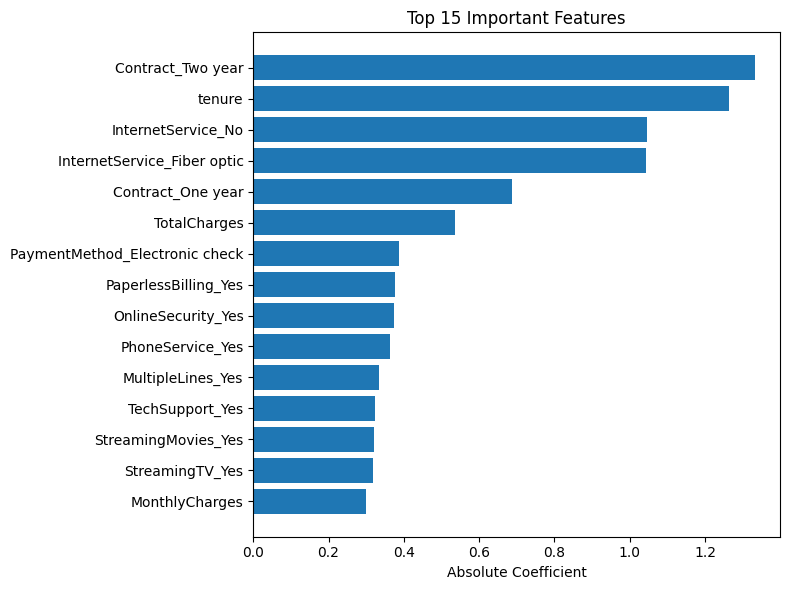

In [251]:
top_features = feature_importance.head(15).sort_values("Abs_Importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Abs_Importance"])
plt.xlabel("Absolute Coefficient")
plt.title("Top 15 Important Features")
plt.tight_layout()
plt.show()

# 10. SHAP

In [252]:
import shap
X_train_transformed = best_model.named_steps["preprocess"].transform(X_train)
X_test_transformed = best_model.named_steps["preprocess"].transform(X_test)

feature_names = get_feature_names_from_pipeline(best_model)

explainer = shap.LinearExplainer(best_model.named_steps["logit"], X_train_transformed)
shap_values = explainer.shap_values(X_test_transformed)

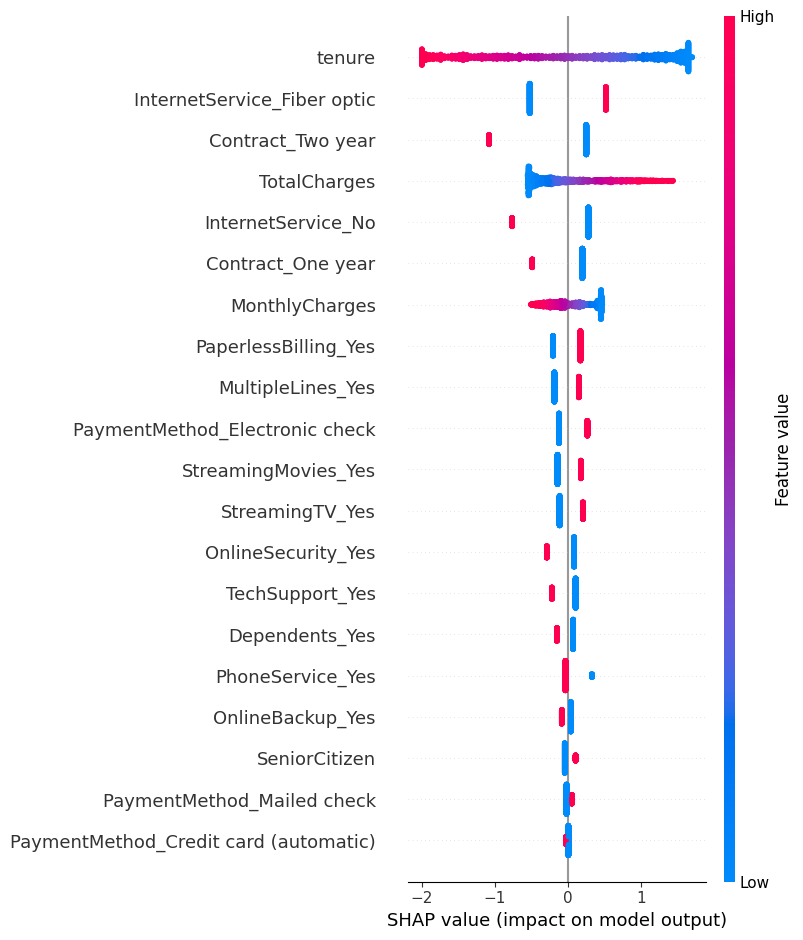

In [253]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [254]:

sv = shap_values[1] if isinstance(shap_values, list) else shap_values

mean_abs_shap = np.abs(sv).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)

display(shap_importance.head(15))

,Feature,MeanAbsSHAP
20,tenure,1.129414
5,InternetService_Fiber optic,0.521674
14,Contract_Two year,0.450080
22,TotalCharges,0.439445
6,InternetService_No,0.388712
13,Contract_One year,0.260647
21,MonthlyCharges,0.256667
15,PaperlessBilling_Yes,0.184704
4,MultipleLines_Yes,0.170420
17,PaymentMethod_Electronic check,0.169730


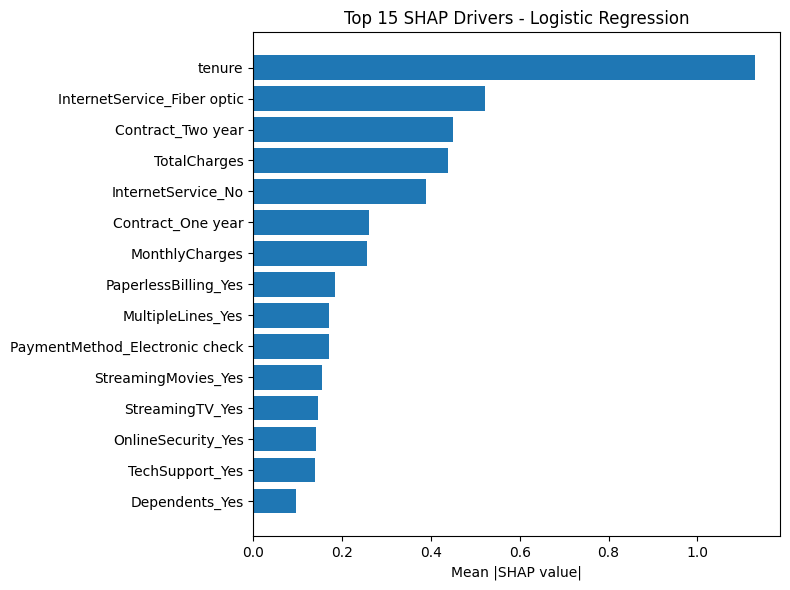

In [255]:
top_shap = shap_importance.head(15).sort_values("MeanAbsSHAP")

plt.figure(figsize=(8, 6))
plt.barh(top_shap["Feature"], top_shap["MeanAbsSHAP"])
plt.xlabel("Mean |SHAP value|")
plt.title(f"Top 15 SHAP Drivers - {best_model_name}")
plt.tight_layout()
plt.show()

In [256]:
final_results_tableau.to_csv("telco_churn_tableau_output.csv", index=False)

# 11. Results Summary

## Model Performance on Test Set

The table below summarises each model's cross validation out-of-sample performance.

| Model | AUC | Accuracy |
|-------|-----|----------|
| Logistic Regression | 0.8459 | 0.8028 |
| Random Forest | 0.8253 | 0.7890 |
| Gradient Boosting | 0.8403 | 0.7978 |

## Key Findings

**Best model:** Based on cross-validated AUC and accuracy, **Logistic Regression** was the best performing model. On this dataset the differences between models are typically small (0.01–0.03 AUC), which itself is a finding worth reporting.

**Top churn drivers** (from SHAP values and feature importance):
- **Contract type** — month-to-month customers churn at dramatically higher rates than 1- or 2-year contract holders
- **Tenure** — newer customers (0–12 months) are at highest risk; churn risk drops significantly after ~24 months
- **Monthly charges** — higher charges correlate with higher churn, especially without added-value services
- **Internet service** — Fiber optic customers churn more than DSL or no-internet customers

## Risk Tier Distribution

Customers are segmented into three actionable tiers based on predicted churn probability:

| Risk Tier | Probability | Recommended Action |
|-----------|------------|-------------------|
| 🟢 Low | < 30% | Standard engagement, no urgent action |
| 🟡 Medium | 30–60% | Proactive outreach, loyalty offers |
| 🔴 High | ≥ 60% | Priority retention — immediate intervention |

## Limitations & Next Steps
- Model could be improved with hyperparameter tuning
- Use this model to directly target customers that are at high risk of churning with proactive retention offers to decrease churn rate